# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Issabela Marian Romero Aguayo"            # Tu nombre completo
MATRICULA = "82275"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Issabela Marian Romero Aguayo
Matrícula: 82275
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\Romero Aguayo\Documents\LASALLE\SEMESTRE 5\TOPICOS BIG DATA\BIG_DATA_ISSABELA\EXAMEN_PRIMER_PARCIAL_82275\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset contiene 4,914 registros y 5 columnas, con información desde 1990 hasta 2024. La variable valor es numérica que representa el número de homicidios. Se observan valores nulos principalmente en las columnas code y owid_region, mientras que entity, year y valor no presentan valores nulos.

In [10]:
print("Año mínimo:", df['year'].min())
print("Año máximo:", df['year'].max())

Año mínimo: 1990
Año máximo: 2024


## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [11]:
# Pregunta 1
# Tu codigo aqui

df_paises = df[df[config["filtro_paises"]].notnull()].copy()

# Cantidad de países distintos
cantidad_paises = df_paises['entity'].nunique()

print("Cantidad de países distintos:", cantidad_paises)

# 10 países con mayor valor
top_10 = (
    df_paises
    .sort_values('valor', ascending=False)
    [['entity', 'year', 'valor']]
    .drop_duplicates('entity')
    .head(10)
)

print("\n10 países con mayor valor:")
print(top_10.to_string(index=False))

# 10 países con menor valor
bottom_10 = (
    df_paises
    .sort_values('valor', ascending=True)
    [['entity', 'year', 'valor']]
    .drop_duplicates('entity')
    .head(10)
)

print("\n10 países con menor valor:")
print(bottom_10.to_string(index=False))

Cantidad de países distintos: 200

10 países con mayor valor:
       entity  year   valor
       Brazil  2017 63788.0
      Nigeria  2016 63400.0
        India  1992 49688.0
       Russia  1994 47870.0
       Mexico  2020 36773.0
     Colombia  1993 28441.0
        China  1995 27356.0
 South Africa  2022 27272.0
United States  1991 24703.0
    Venezuela  2014 19030.0

10 países con menor valor:
                  entity  year  valor
                 Vatican  2011    0.0
                Anguilla  1994    0.0
                 Iceland  2008    0.0
              San Marino  2008    0.0
                 Bahrain  2020    0.0
                 Andorra  2013    0.0
            Saint Helena  1994    0.0
Turks and Caicos Islands  1991    0.0
              Montserrat  2017    0.0
  British Virgin Islands  1991    0.0


**Interpretación:**

El dataset contiene información de 200 países distintos. Los países con los valores más altos registrados son Brasil, Nigeria, India, Rusia y México, mientras que entre los valores más bajos se encuentran países y territorios pequeños como Vaticano, Anguilla, Islandia y San Marino, que presentan valores de 0 homicidios en algunos años. Esto muestra una gran diferencia en el número de homicidios entre los países analizados, especialmente entre los países con mayor población y los territorios con menor población.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [12]:
# Pregunta 2
# Tu codigo aqui

# Países seleccionados
pais1 = "Mexico"
pais2 = "Brazil"

# Filtrar los datos de ambos países
datos_paises = df_paises[
    df_paises['entity'].isin([pais1, pais2])
].copy()

# Obtener años disponibles para cada país
anios_pais1 = set(
    datos_paises[datos_paises['entity'] == pais1]['year']
)

anios_pais2 = set(
    datos_paises[datos_paises['entity'] == pais2]['year']
)

# Encontrar los años disponibles para ambos
anios_comunes = sorted(anios_pais1.intersection(anios_pais2))

# Primer y último año en común
anio_inicio = min(anios_comunes)
anio_fin = max(anios_comunes)

# Filtrar únicamente el rango común
resultado_p2 = datos_paises[
    datos_paises['year'].between(anio_inicio, anio_fin)
].sort_values(['year', 'entity'])

print("Países seleccionados:", pais1, "y", pais2)
print("Rango de años en común:", anio_inicio, "-", anio_fin)
print("\nDatos:")
print(resultado_p2[['entity', 'year', 'valor']].to_string(index=False))

Países seleccionados: Mexico y Brazil
Rango de años en común: 1990 - 2023

Datos:
entity  year     valor
Brazil  1990 29301.190
Mexico  1990 14493.000
Brazil  1991 28148.473
Mexico  1991 15128.000
Brazil  1992 25966.840
Mexico  1992 16594.000
Brazil  1993 28012.752
Mexico  1993 16040.000
Brazil  1994 29851.412
Mexico  1994 15839.000
Brazil  1995 34000.090
Mexico  1995 15612.000
Brazil  1996 38894.000
Mexico  1996 14505.000
Brazil  1997 40507.000
Mexico  1997 13552.000
Brazil  1998 41950.000
Mexico  1998 13656.000
Brazil  1999 42914.000
Mexico  1999 12249.000
Brazil  2000 45375.000
Mexico  2000 10737.000
Brazil  2001 47955.000
Mexico  2001 10285.000
Brazil  2002 49710.000
Mexico  2002 10088.000
Brazil  2003 51064.000
Mexico  2003 10087.000
Brazil  2004 48394.000
Mexico  2004  9329.000
Brazil  2005 47593.000
Mexico  2005  9921.000
Brazil  2006 49165.000
Mexico  2006 10452.000
Brazil  2007 47731.000
Mexico  2007  8867.000
Brazil  2008 50135.000
Mexico  2008 14006.000
Brazil  2009 51461.00

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [13]:
# Pregunta 3
# Tu codigo aqui

# Cinco países de distintos continentes
paises_p3 = [
    "Mexico",
    "Spain",
    "China",
    "Nigeria",
    "Australia"
]

# Filtrar los países seleccionados
datos_p3 = df_paises[
    df_paises['entity'].isin(paises_p3)
].copy()

# Encontrar los años disponibles para todos los países
anios_por_pais = [
    set(datos_p3[datos_p3['entity'] == pais]['year'])
    for pais in paises_p3
]

anios_comunes = set.intersection(*anios_por_pais)

# Año más reciente disponible para los cinco
anio_reciente = max(anios_comunes)

# Datos del año más reciente
comparacion_p3 = (
    datos_p3[datos_p3['year'] == anio_reciente]
    [['entity', 'year', 'valor']]
    .sort_values('valor', ascending=False)
)

print("Año más reciente disponible para los cinco países:", anio_reciente)
print("\nComparación:")
print(comparacion_p3.to_string(index=False))

# País con valor más alto y más bajo
pais_max = comparacion_p3.iloc[0]
pais_min = comparacion_p3.iloc[-1]

diferencia = pais_max['valor'] - pais_min['valor']

print("\nPaís con valor más alto:")
print(pais_max.to_string())

print("\nPaís con valor más bajo:")
print(pais_min.to_string())

print("\nDiferencia entre ambos:", diferencia)

Año más reciente disponible para los cinco países: 2019

Comparación:
   entity  year   valor
  Nigeria  2019 44200.0
   Mexico  2019 36661.0
    China  2019  7379.0
    Spain  2019   331.0
Australia  2019   225.0

País con valor más alto:
entity    Nigeria
year         2019
valor     44200.0

País con valor más bajo:
entity    Australia
year           2019
valor         225.0

Diferencia entre ambos: 43975.0


**Interpretación:**

En 2019, Nigeria presentó el valor más alto con 44,200 homicidios, mientras que Australia tuvo el valor más bajo con 225. La diferencia entre ambos países fue de 43,975 homicidios, lo que muestra una gran variación entre los países analizados.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [14]:
# Pregunta 4
# Tu codigo aqui

# Definir los grupos
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

todos_paises_p4 = latinoamerica + asia

# Filtrar los países
datos_p4 = df_paises[
    df_paises['entity'].isin(todos_paises_p4)
].copy()

# Obtener años disponibles para cada país
anios_por_pais = [
    set(datos_p4[datos_p4['entity'] == pais]['year'])
    for pais in todos_paises_p4
]

# Años disponibles para todos
anios_comunes = set.intersection(*anios_por_pais)

# Año más reciente disponible para los seis
anio_reciente_p4 = max(anios_comunes)

# Filtrar ese año
datos_recientes_p4 = datos_p4[
    datos_p4['year'] == anio_reciente_p4
].copy()

# Calcular promedios
promedio_latinoamerica = datos_recientes_p4[
    datos_recientes_p4['entity'].isin(latinoamerica)
]['valor'].mean()

promedio_asia = datos_recientes_p4[
    datos_recientes_p4['entity'].isin(asia)
]['valor'].mean()

print("Año utilizado:", anio_reciente_p4)

print("\nPromedio Latinoamérica:")
print(promedio_latinoamerica)

print("\nPromedio Asia:")
print(promedio_asia)

print("\nDatos utilizados:")
print(
    datos_recientes_p4[['entity', 'valor']]
    .sort_values('valor', ascending=False)
    .to_string(index=False)
)

Año utilizado: 2011

Promedio Latinoamérica:
15283.666666666666

Promedio Asia:
4605.0

Datos utilizados:
   entity   valor
   Mexico 27213.0
 Colombia 16127.0
    China 12015.0
Argentina  2511.0
  Vietnam  1358.0
    Japan   442.0


**Interpretación:**

En 2011, el promedio de homicidios de los países seleccionados de Latinoamérica fue de 15,283.67, mientras que el promedio de los países seleccionados de Asia fue de 4,605. Esto indica que, dentro de los países analizados, Latinoamérica presentó un promedio de homicidios considerablemente mayor que Asia.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [15]:
# Pregunta 5
# Tu codigo aqui

pais_p5 = "Mexico"

# Filtrar México
mexico = df_paises[
    df_paises['entity'] == pais_p5
].copy()

# Ordenar por año
mexico = mexico.sort_values('year')

# Año con valor máximo
registro_max = mexico.loc[mexico['valor'].idxmax()]

# Año con valor mínimo
registro_min = mexico.loc[mexico['valor'].idxmin()]

print("País:", pais_p5)

print("\nAño con valor máximo:")
print("Año:", int(registro_max['year']))
print("Valor:", registro_max['valor'])

print("\nAño con valor mínimo:")
print("Año:", int(registro_min['year']))
print("Valor:", registro_min['valor'])

print("\nDatos completos:")
print(mexico[['year', 'valor']].to_string(index=False))

País: Mexico

Año con valor máximo:
Año: 2020
Valor: 36773.0

Año con valor mínimo:
Año: 2007
Valor: 8867.0

Datos completos:
 year   valor
 1990 14493.0
 1991 15128.0
 1992 16594.0
 1993 16040.0
 1994 15839.0
 1995 15612.0
 1996 14505.0
 1997 13552.0
 1998 13656.0
 1999 12249.0
 2000 10737.0
 2001 10285.0
 2002 10088.0
 2003 10087.0
 2004  9329.0
 2005  9921.0
 2006 10452.0
 2007  8867.0
 2008 14006.0
 2009 19803.0
 2010 25757.0
 2011 27213.0
 2012 25967.0
 2013 23063.0
 2014 20010.0
 2015 20762.0
 2016 24559.0
 2017 32079.0
 2018 36685.0
 2019 36661.0
 2020 36773.0
 2021 35700.0
 2022 33287.0
 2023 32252.0


**Interpretación:**

En México, el número de homicidios alcanzó su valor máximo en 2020, con 36,773 homicidios, mientras que el mínimo se presentó en 2007, con 8,867. La tendencia general es fluctuante, aunque se observa un incremento importante a partir de 2008 y un aumento hasta alcanzar niveles elevados entre 2017 y 2020, seguido de una disminución en los últimos años disponibles.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [16]:
# Pregunta 6
# Tu codigo aqui

pais_p6 = "Mexico"

# Filtrar México
mexico_p6 = df_paises[
    df_paises['entity'] == pais_p6
].sort_values('year').copy()

# Primer y último registro disponible
primer_registro = mexico_p6.iloc[0]
ultimo_registro = mexico_p6.iloc[-1]

valor_inicial = primer_registro['valor']
valor_final = ultimo_registro['valor']

anio_inicial = int(primer_registro['year'])
anio_final = int(ultimo_registro['year'])

# Calcular cambio porcentual
cambio_porcentual = (
    (valor_final - valor_inicial) / valor_inicial
) * 100

print("País:", pais_p6)
print("Primer año:", anio_inicial)
print("Valor inicial:", valor_inicial)
print("Último año:", anio_final)
print("Valor final:", valor_final)
print(f"Cambio porcentual: {cambio_porcentual:.2f}%")

if cambio_porcentual > 0:
    print("Resultado: incremento relativo")
elif cambio_porcentual < 0:
    print("Resultado: caída")
else:
    print("Resultado: sin cambio")

País: Mexico
Primer año: 1990
Valor inicial: 14493.0
Último año: 2023
Valor final: 32252.0
Cambio porcentual: 122.54%
Resultado: incremento relativo


**Interpretación:**

Entre 1990 y 2023, México presentó un incremento relativo de 122.54% en el número de homicidios registrados, pasando de 14,493 a 32,252. El resultado muestra que, a pesar de las variaciones durante este periodo, el valor final fue considerablemente mayor al inicial. Este comportamiento puede estar relacionado con cambios en factores sociales y económicos, como el aumento de la violencia e inseguridad en las calles.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [17]:
# Pregunta 7
# Tu codigo aqui

# Año más reciente disponible en los países reales
anio_reciente_p7 = df_paises['year'].max()

# Filtrar el año más reciente
datos_p7 = df_paises[
    df_paises['year'] == anio_reciente_p7
].copy()

# Eliminar valores NaN de la columna valor
valores = datos_p7['valor'].dropna().to_numpy()

# Estadísticas con NumPy
media = np.mean(valores)
mediana = np.median(valores)
desviacion_estandar = np.std(valores)

print("Año analizado:", anio_reciente_p7)
print("Cantidad de países:", len(valores))
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación estándar: {desviacion_estandar:.2f}")

Año analizado: 2024
Cantidad de países: 10
Media: 1402.50
Mediana: 209.50
Desviación estándar: 3319.74


**Interpretación:**

En 2024 se analizaron únicamente 10 países con información disponible. La media fue de 1,402.50 homicidios, mientras que la mediana fue de 209.50, lo que indica que algunos valores elevados afectan considerablemente la media. La desviación estándar de 3,319.74 también muestra una alta dispersión entre los valores registrados.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

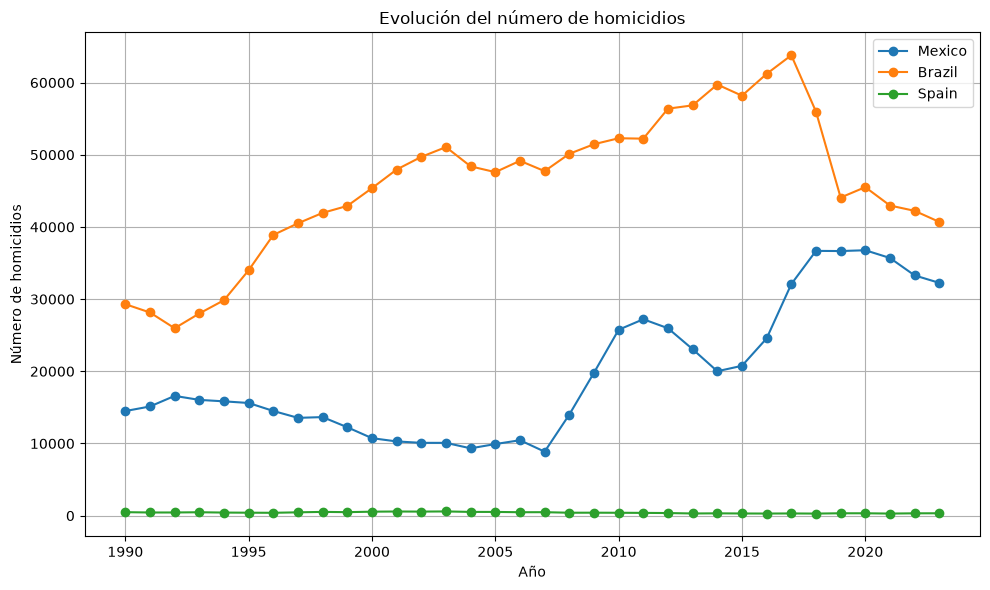

In [18]:
# Pregunta 8
# Tu codigo aqui

paises_p8 = ["Mexico", "Brazil", "Spain"]

# Filtrar los tres países
datos_p8 = df_paises[
    df_paises['entity'].isin(paises_p8)
].copy()

# Crear gráfica
plt.figure(figsize=(10, 6))

for pais in paises_p8:
    datos_pais = datos_p8[
        datos_p8['entity'] == pais
    ].sort_values('year')
    
    plt.plot(
        datos_pais['year'],
        datos_pais['valor'],
        marker='o',
        label=pais
    )

plt.title("Evolución del número de homicidios")
plt.xlabel("Año")
plt.ylabel("Número de homicidios")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# Revisar los datos de los tres países

paises_p8 = ["Mexico", "Brazil", "Spain"]

revision_p8 = (
    df_paises[df_paises['entity'].isin(paises_p8)]
    [['entity', 'year', 'valor']]
    .sort_values(['entity', 'year'])
)

print(revision_p8.to_string(index=False))

entity  year       valor
Brazil  1990 29301.19000
Brazil  1991 28148.47300
Brazil  1992 25966.84000
Brazil  1993 28012.75200
Brazil  1994 29851.41200
Brazil  1995 34000.09000
Brazil  1996 38894.00000
Brazil  1997 40507.00000
Brazil  1998 41950.00000
Brazil  1999 42914.00000
Brazil  2000 45375.00000
Brazil  2001 47955.00000
Brazil  2002 49710.00000
Brazil  2003 51064.00000
Brazil  2004 48394.00000
Brazil  2005 47593.00000
Brazil  2006 49165.00000
Brazil  2007 47731.00000
Brazil  2008 50135.00000
Brazil  2009 51461.00000
Brazil  2010 52289.00000
Brazil  2011 52233.00000
Brazil  2012 56388.00000
Brazil  2013 56845.00000
Brazil  2014 59733.00000
Brazil  2015 58184.00000
Brazil  2016 61208.00000
Brazil  2017 63788.00000
Brazil  2018 55980.00000
Brazil  2019 44073.00000
Brazil  2020 45515.00000
Brazil  2021 42968.00000
Brazil  2022 42232.00000
Brazil  2023 40698.00000
Mexico  1990 14493.00000
Mexico  1991 15128.00000
Mexico  1992 16594.00000
Mexico  1993 16040.00000
Mexico  1994 15839.00000


In [20]:
# Ver los valores máximos de cada país en P8

maximos_p8 = (
    df_paises[df_paises['entity'].isin(["Mexico", "Brazil", "Spain"])]
    .groupby('entity')['valor']
    .max()
    .sort_values(ascending=False)
)

print(maximos_p8)

entity
Brazil    63788.0
Mexico    36773.0
Spain       587.0
Name: valor, dtype: float64


**Interpretación:**

La gráfica muestra que Brasil y México presentan los valores más altos de homicidios durante el periodo analizado, con variaciones importantes a lo largo de los años. España presenta valores considerablemente menores en comparación con ambos países, por lo que su línea se observa cercana al eje cero debido a la diferencia de escala. En general, Brasil y México muestran una mayor magnitud de homicidios, mientras que España mantiene valores relativamente bajos.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

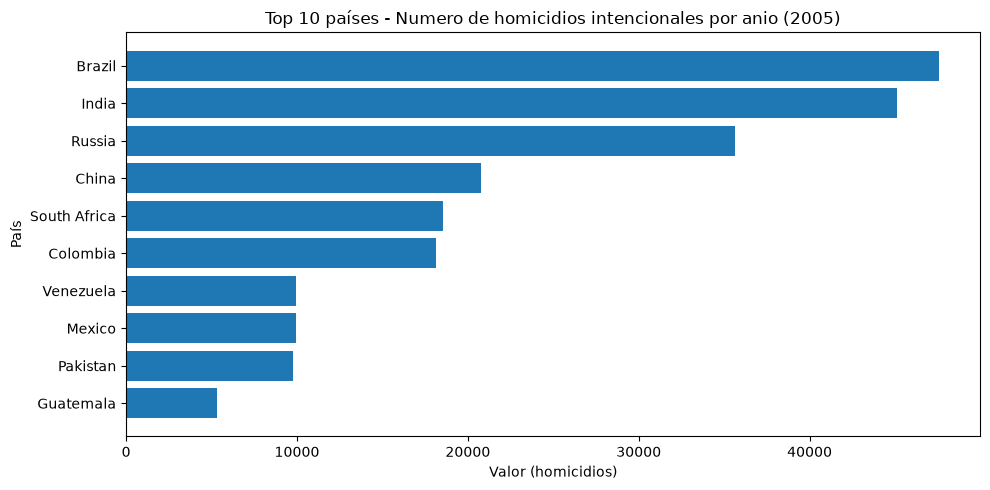

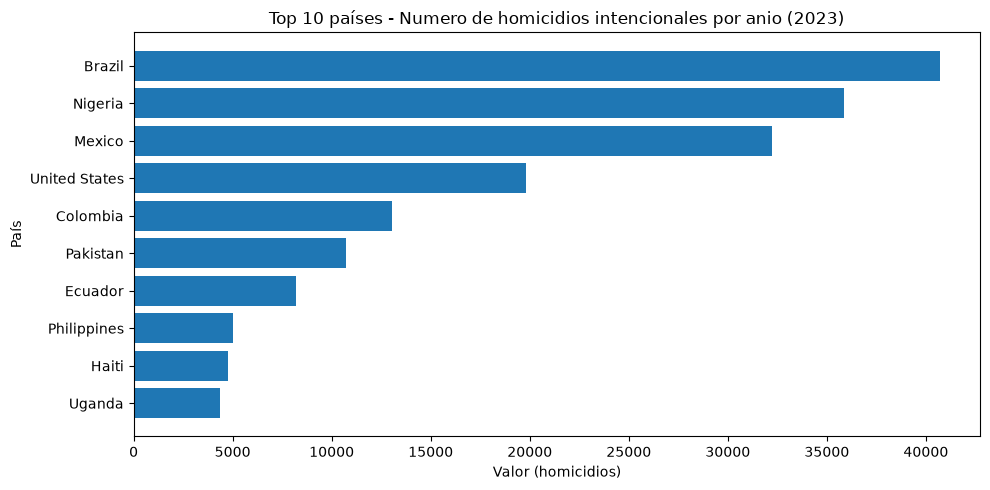

TOP 10 - 2005
      entity   valor
      Brazil 47593.0
       India 45095.0
      Russia 35636.0
       China 20770.0
South Africa 18528.0
    Colombia 18111.0
   Venezuela  9964.0
      Mexico  9921.0
    Pakistan  9782.0
   Guatemala  5338.0

TOP 10 - 2023
       entity   valor
       Brazil 40698.0
      Nigeria 35884.0
       Mexico 32252.0
United States 19796.0
     Colombia 13035.0
     Pakistan 10729.0
      Ecuador  8221.0
  Philippines  4995.0
        Haiti  4789.0
       Uganda  4366.0


In [21]:
# Pregunta 9

df_paises = df[df[config["filtro_paises"]].notnull()].copy()

# Años solicitados
anio_nacimiento = 2005
anio_2023 = 2023

# =========================
# TOP 10 DEL AÑO 2005
# =========================

top_2005 = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_2005['entity'],
    top_2005['valor']
)

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(
    f"Top 10 países - {config['descripcion']} ({anio_nacimiento})"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# =========================
# TOP 10 DEL AÑO 2023
# =========================

top_2023 = (
    df_paises[df_paises['year'] == anio_2023]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.barh(
    top_2023['entity'],
    top_2023['valor']
)

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(
    f"Top 10 países - {config['descripcion']} ({anio_2023})"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# Mostrar los datos para comparar los movimientos
print("TOP 10 - 2005")
print(
    top_2005[['entity', 'valor']]
    .to_string(index=False)
)

print("\nTOP 10 - 2023")
print(
    top_2023[['entity', 'valor']]
    .to_string(index=False)
)

**Interpretación:**

Entre 2005 y 2023 hubo cambios importantes en la composición del Top 10. Brasil permaneció en el primer lugar, aunque disminuyó de 47,593 a 40,698 homicidios. India, Rusia, China, Sudáfrica, Venezuela y Guatemala salieron del Top 10, mientras que Nigeria, Estados Unidos, Ecuador, Filipinas, Haití y Uganda ingresaron. México también mostró un cambio importante, pasando del octavo lugar en 2005 al tercer lugar en 2023.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Durante el análisis del dataset de homicidios aprendí a explorar, filtrar y comparar datos de diferentes países y años. Se encontraron diferencias importantes entre los países, destacando valores mucho mayores en países como Brasil, Nigeria y México. También se observaron variaciones significativas a lo largo del tiempo, especialmente en el caso de México. Una limitación importante es que los datos representan valores absolutos, por lo que no consideran el tamaño de la población de cada país. Además, existen valores faltantes en algunas columnas y no todos los países cuentan con información para los mismos años. Si tuviera más tiempo, realizaría un análisis utilizando tasas de homicidios por cada 100,000 habitantes para obtener comparaciones más justas. También analizaría con mayor detalle los valores atípicos y la evolución de los homicidios por región.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
